## Cluster-by-bin Heatmaps Using maxrayleigh_tuned Cell IDs

This notebook rebuilds the A/B heatmaps using the filtered IDs from:
- `tuned_ids_A_preflip_AND_maxrayleighA.csv`
- `tuned_ids_B_postflip_AND_maxrayleighB.csv`

It pulls firing arrays from `linked_tuned_ids_to_rayleigh_long.csv`, expands them into directional bins, and plots A vs B heatmaps.


In [5]:
import ast
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SAVE_ROOT = Path(r"/ceph/branco/Jasmine_Laurence/rayleigh_analysis/Top2_TunED")
LINKED_CSV = SAVE_ROOT / "linked_tuned_ids_to_rayleigh_long.csv"
A_IDS_CSV = SAVE_ROOT / "tuned_ids_A_preflip_AND_maxrayleighA.csv"
B_IDS_CSV = SAVE_ROOT / "tuned_ids_B_postflip_AND_maxrayleighB.csv"

# Same bin logic used in existing angle-bin scripts
NUMBER_OF_BINS = 13  # 13 edges -> 12 centers
START_RAD = -np.pi
STOP_RAD = np.pi


In [6]:
def generate_bins(number_of_bins: int, start: float = -np.pi, stop: float = np.pi):
    bin_angles = np.linspace(start, stop, number_of_bins)
    bin_angle_center = bin_angles[:-1] + (np.mean(np.diff(bin_angles)) / 2)
    return bin_angles, bin_angle_center


def parse_array(val):
    if isinstance(val, (list, tuple, np.ndarray)):
        arr = np.asarray(val, dtype=float).reshape(-1)
        return arr[np.isfinite(arr)]
    if pd.isna(val):
        return np.asarray([], dtype=float)
    s = str(val).strip()
    if not s:
        return np.asarray([], dtype=float)
    try:
        parsed = ast.literal_eval(s)
        arr = np.asarray(parsed, dtype=float).reshape(-1)
        return arr[np.isfinite(arr)]
    except Exception:
        s = s.strip("[]")
        arr = np.fromstring(s, sep=" ", dtype=float)
        return arr[np.isfinite(arr)]


def build_long_by_bin(df: pd.DataFrame) -> pd.DataFrame:
    _, bin_centers = generate_bins(NUMBER_OF_BINS, START_RAD, STOP_RAD)
    n_bins = len(bin_centers)
    rows = []

    for _, row in df.iterrows():
        fr = parse_array(row.get("firing_rate_hz", np.nan))
        if fr.size == 0:
            continue
        m = min(fr.size, n_bins)
        for i in range(m):
            rows.append({
                "session": row.get("session"),
                "cluster_id": row.get("cluster_id"),
                "condition": row.get("condition"),
                "tuned_label": row.get("tuned_label"),
                "bin_index": i,
                "bin_center_deg": float(np.degrees(bin_centers[i])),
                "firing_rate_hz_bin": float(fr[i]),
            })

    out = pd.DataFrame(rows)
    if out.empty:
        return out
    out["bin_label"] = out["bin_center_deg"].map(lambda x: f"{x:.0f}°")
    return out


In [7]:
for p in [LINKED_CSV, A_IDS_CSV, B_IDS_CSV]:
    if not p.exists():
        raise FileNotFoundError(f"Missing file: {p}")

linked = pd.read_csv(LINKED_CSV)
a_ids = pd.read_csv(A_IDS_CSV)[["session", "condition", "cluster_id"]].copy()
b_ids = pd.read_csv(B_IDS_CSV)[["session", "condition", "cluster_id"]].copy()

a_ids["tuned_label"] = "A_only"
b_ids["tuned_label"] = "B_only"
targets = pd.concat([a_ids, b_ids], ignore_index=True).drop_duplicates()

# Keep only rows matching new max-rayleigh-filtered IDs
filt = linked.merge(targets, on=["session", "condition", "cluster_id"], how="inner", suffixes=("", "_new"))
filt["tuned_label"] = filt["tuned_label_new"]
filt = filt.drop(columns=["tuned_label_new"])

print(f"Linked rows total: {len(linked)}")
print(f"Target cell IDs (A+B): {targets.shape[0]}")
print(f"Rows after filtering to new IDs: {len(filt)}")
print(f"Unique filtered cells: {filt[['session', 'condition', 'cluster_id']].drop_duplicates().shape[0]}")

dist_df = build_long_by_bin(filt)
print(f"Expanded rows (cell x directional bin): {len(dist_df)}")


Linked rows total: 410
Target cell IDs (A+B): 72
Rows after filtering to new IDs: 72
Unique filtered cells: 72
Expanded rows (cell x directional bin): 864


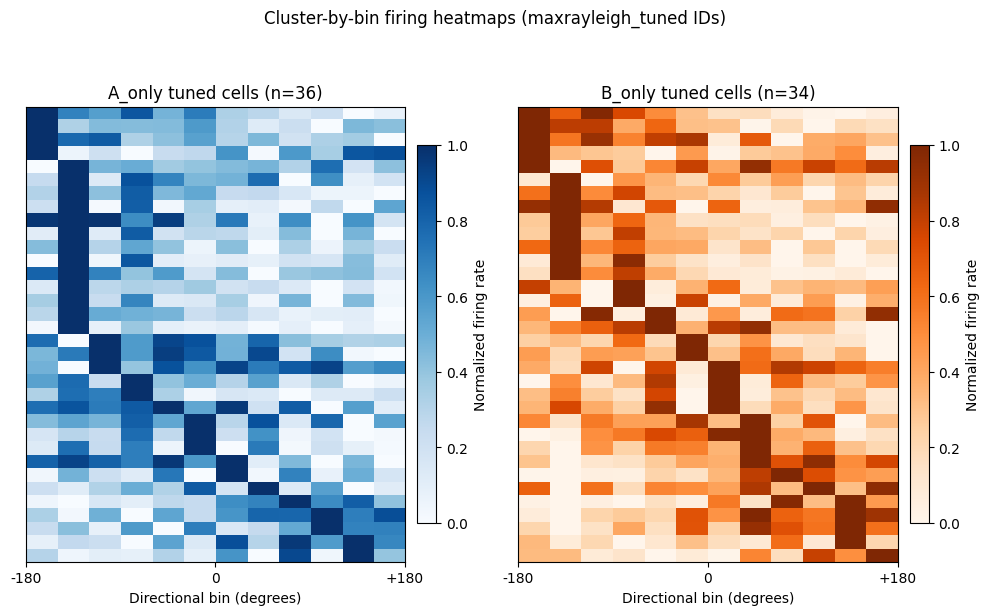

In [15]:
# Heatmap: x=directional bin (deg), y=cluster_id sorted for snake-like visual pattern
labels = ["A_only", "B_only"]
cmaps = {"A_only": "Blues", "B_only": "Oranges"}


def snake_cluster_order(mat: pd.DataFrame, x_order):
    """
    Serpentine sort:
    1) assign each cluster to preferred-bin index (argmax),
    2) walk preferred bins from left->right,
    3) within each bin, alternate sort direction by center-of-mass.
    """
    x_idx = np.arange(len(x_order), dtype=float)
    rows = []

    for cid, vals in mat.iterrows():
        arr = vals.to_numpy(dtype=float)
        if not np.isfinite(arr).any():
            continue
        arr = np.nan_to_num(arr, nan=0.0)
        pref_idx = int(np.argmax(arr))
        denom = float(arr.sum())
        com = float((arr * x_idx).sum() / denom) if denom > 0 else float(pref_idx)
        peak = float(arr[pref_idx])
        rows.append((cid, pref_idx, com, peak))

    if not rows:
        return mat.index.tolist()

    meta = pd.DataFrame(rows, columns=["cluster_id", "pref_idx", "com", "peak"])

    ordered = []
    for k, pref_idx in enumerate(sorted(meta["pref_idx"].unique())):
        g = meta[meta["pref_idx"] == pref_idx].copy()
        asc = (k % 2 == 0)  # alternate direction -> snake effect
        g = g.sort_values(["com", "peak", "cluster_id"], ascending=[asc, False, True])
        ordered.extend(g["cluster_id"].tolist())

    return ordered


def row_minmax_normalize(mat: pd.DataFrame) -> pd.DataFrame:
    arr = mat.to_numpy(dtype=float)
    out = np.full_like(arr, np.nan, dtype=float)

    for i in range(arr.shape[0]):
        row = arr[i]
        valid = np.isfinite(row)
        if not valid.any():
            continue
        lo = np.nanmin(row)
        hi = np.nanmax(row)
        if np.isfinite(lo) and np.isfinite(hi) and hi > lo:
            out[i, valid] = (row[valid] - lo) / (hi - lo)
        else:
            out[i, valid] = 0.0

    return pd.DataFrame(out, index=mat.index, columns=mat.columns)


fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharey=True)

for ax, lab in zip(axes, labels):
    sub = dist_df[dist_df["tuned_label"] == lab].copy()

    if sub.empty:
        ax.text(0.5, 0.5, f"No data for {lab}", ha="center", va="center", transform=ax.transAxes)
        n_cells = len(cluster_order)
        ax.set_title(f"{lab} tuned cells (n={n_cells})")
        ax.set_xlabel("Directional bin (degrees)")
        continue

    mat_long = (
        sub.groupby(["cluster_id", "bin_center_deg"], observed=True)["firing_rate_hz_bin"]
        .mean()
        .reset_index()
    )

    x_order = sorted(sub["bin_center_deg"].dropna().unique())

    base_mat = (
        mat_long.pivot(index="cluster_id", columns="bin_center_deg", values="firing_rate_hz_bin")
        .reindex(columns=x_order)
    )

    cluster_order = snake_cluster_order(base_mat, x_order)

    mat = base_mat.reindex(index=cluster_order)
    mat_norm = row_minmax_normalize(mat)

    # Use bin-edge coordinates so 0 deg is exactly between the two middle bins.
    im = ax.imshow(
        mat_norm.to_numpy(dtype=float),
        origin="lower",
        aspect="auto",
        cmap=cmaps[lab],
        interpolation="nearest",
        vmin=0.0,
        vmax=1.0,
        extent=[-180, 180, -0.5, len(cluster_order) - 0.5],
    )

    n_cells = len(cluster_order)
    ax.set_title(f"{lab} tuned cells (n={n_cells})")
    ax.set_xlabel("Directional bin (degrees)")
    ax.set_box_aspect(1.2)  # makes x-axis visually narrower like reference

    # Label bin edges directly so 0 is centered between central bins.
    ax.set_xticks([-180, 0, 180])
    ax.set_xticklabels(["-180", "0", "+180"])

    ax.set_yticks([])
    ax.invert_yaxis()

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
    cbar.set_label("Normalized firing rate")

fig.suptitle("Cluster-by-bin firing heatmaps (maxrayleigh_tuned IDs)", y=1.02)
fig.tight_layout()


fig.savefig("/ceph/branco/Laurence/thesis/efizz_chapter/cluster_by_fr_heat_barrier.eps")
plt.show()







